In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [3]:
import pandas as pd

nav = pd.read_csv("../data/raw/02_nav_history.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print(nav.columns)

print("\n")

print(benchmark.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


Index(['date', 'index_name', 'close_value'], dtype='str')


In [4]:
# Convert date column

nav["date"] = pd.to_datetime(nav["date"])

# Sort data

nav = nav.sort_values(
    ["amfi_code", "date"]
)

# Calculate daily return

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# View results

nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [5]:
print(nav[["amfi_code",
           "date",
           "nav",
           "daily_return"]].head(20))

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
5756     100016 2022-01-11  513.5542      0.005562
5757     100016 2022-01-12  512.3195     -0.002404
5758     100016 2022-01-13  510.2445     -0.004050
5759     100016 2022-01-14  514.3636      0.008073
5760     100016 2022-01-17  514.7627      0.000776
5761     100016 2022-01-18  517.3803      0.005085
5762     100016 2022-01-19  513.1866     -0.008106
5763     100016 2022-01-20  507.1294     -0.011803
5764     100016 2022-01-21  507.8710      0.001462
5765     100016 2022-01-24  506.7062     -0.002293
5766     100016 2022-01-25  509.7762      0.006059
5767     100016 2022-01-26  509.6800     -0.000189
5768     100016 2022-01-27  510

In [6]:
# First NAV for each fund

start_nav = nav.groupby("amfi_code")["nav"].first()

# Last NAV for each fund

end_nav = nav.groupby("amfi_code")["nav"].last()

# Number of years

years = (
    nav.groupby("amfi_code")["date"].max()
    -
    nav.groupby("amfi_code")["date"].min()
).dt.days / 365

# CAGR formula

cagr = (
    (end_nav / start_nav) ** (1 / years)
) - 1

# Create table

cagr_table = pd.DataFrame({
    "start_nav": start_nav,
    "end_nav": end_nav,
    "years": years,
    "cagr": cagr
})

# Show top rows

cagr_table.head()

,start_nav,end_nav,years,cagr
amfi_code,,,,
100016,520.4608,583.6113,4.40274,0.026352
100025,26.3169,31.8843,4.40274,0.044551
100033,107.3758,342.0072,4.40274,0.300997
101206,305.0996,773.2939,4.40274,0.235205
101207,38.5736,53.9836,4.40274,0.079331


In [7]:
print(cagr_table.head(10))

           start_nav   end_nav    years      cagr
amfi_code                                        
100016      520.4608  583.6113  4.40274  0.026352
100025       26.3169   31.8843  4.40274  0.044551
100033      107.3758  342.0072  4.40274  0.300997
101206      305.0996  773.2939  4.40274  0.235205
101207       38.5736   53.9836  4.40274  0.079331
101208      310.7415  410.1021  4.40274  0.065044
102885       89.8728  187.7797  4.40274  0.182188
102886      119.2905  125.5640  4.40274  0.011709
102887      191.0721  378.9657  4.40274  0.168287
118632       42.8339  110.5554  4.40274  0.240312


In [10]:
# Risk free rate

rf = 0.065

# Mean daily return

mean_return = (
    nav.groupby("amfi_code")
       ["daily_return"]
       .mean()
)

# Daily volatility

std_return = (
    nav.groupby("amfi_code")
       ["daily_return"]
       .std()
)

# Annualized Sharpe Ratio

sharpe = (
    (mean_return * 252 - rf)
    /
    (std_return * np.sqrt(252))
)

# Create table

sharpe_table = pd.DataFrame({
    "sharpe_ratio": sharpe
})

# Sort best funds first

sharpe_table = (
    sharpe_table
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
)

sharpe_table.head(10)

,sharpe_ratio
amfi_code,
148567,1.448291
120843,1.306744
148569,1.234930
119551,1.208267
120505,1.180101
149323,1.132122
100033,1.093699
118632,1.081659
101206,1.027213


In [12]:
# Negative returns only

downside_returns = nav.copy()

downside_returns["daily_return"] = (
    downside_returns["daily_return"]
    .where(
        downside_returns["daily_return"] < 0
    )
)

# Downside deviation

downside_std = (
    downside_returns
    .groupby("amfi_code")
    ["daily_return"]
    .std()
)

# Sortino Ratio

sortino = (
    (mean_return * 252 - rf)
    /
    (downside_std * np.sqrt(252))
)

# Create table

sortino_table = pd.DataFrame({
    "sortino_ratio": sortino
})

sortino_table = (
    sortino_table
    .sort_values(
        "sortino_ratio",
        ascending=False
    )
)

print(sortino_table.head(10))

           sortino_ratio
amfi_code               
148567          2.385644
120843          2.364320
148569          2.146914
119551          2.140267
120505          2.029353
149323          1.875101
118632          1.850133
100033          1.829134
120504          1.805294
101206          1.799563


In [13]:
# Running maximum NAV

nav["running_max"] = (
    nav.groupby("amfi_code")["nav"]
       .cummax()
)

# Drawdown

nav["drawdown"] = (
    nav["nav"]
    /
    nav["running_max"]
    - 1
)

# Maximum Drawdown per fund

max_dd = (
    nav.groupby("amfi_code")
       ["drawdown"]
       .min()
)

max_dd_table = pd.DataFrame({
    "max_drawdown": max_dd
})

max_dd_table = (
    max_dd_table
    .sort_values(
        "max_drawdown"
    )
)

print(max_dd_table.head(10))

           max_drawdown
amfi_code              
119599        -0.525742
119095        -0.516778
101207        -0.354469
149324        -0.311719
119598        -0.287060
102886        -0.280011
100016        -0.247344
120842        -0.240035
118634        -0.233449
119093        -0.217514


In [14]:
print(benchmark.head())

print("\n")

print(
    benchmark["index_name"]
    .unique()
)

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [15]:
# Select NIFTY100 only

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

# Convert date

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

# Sort

nifty100 = nifty100.sort_values(
    "date"
)

# Benchmark returns

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [16]:
from scipy.stats import linregress

alpha_beta_list = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100[
            ["date",
             "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        slope, intercept, r, p, se = (
            linregress(
                merged["benchmark_return"],
                merged["daily_return"]
            )
        )

        alpha_beta_list.append([
            fund,
            intercept * 252,
            slope
        ])

alpha_beta = pd.DataFrame(
    alpha_beta_list,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [17]:
alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [19]:
performance = pd.read_csv(
    "../data/raw/07_scheme_performance.csv"
)

print(performance.head())

   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct           20.59           23.14           21.82   
4       Gilt  Regular            5.34            6.07            5.43   

   benchmark_3yr_pct  alpha  beta  sharpe_ratio  sortino_ratio  \
0              11.49

In [20]:
scorecard = performance.copy()

print(scorecard.head())

   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct           20.59           23.14           21.82   
4       Gilt  Regular            5.34            6.07            5.43   

   benchmark_3yr_pct  alpha  beta  sharpe_ratio  sortino_ratio  \
0              11.49

In [21]:
performance = pd.read_csv(
    "../data/raw/07_scheme_performance.csv"
)

In [22]:
scorecard = performance.copy()

print(scorecard.head())

   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct           20.59           23.14           21.82   
4       Gilt  Regular            5.34            6.07            5.43   

   benchmark_3yr_pct  alpha  beta  sharpe_ratio  sortino_ratio  \
0              11.49

In [23]:
# Rank based on 3-year return

scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(pct=True)
)

print(
    scorecard[
        ["scheme_name",
         "return_3yr_pct",
         "return_rank"]
    ].head()
)

                                    scheme_name  return_3yr_pct  return_rank
0     SBI Bluechip Fund - Regular Plan - Growth           12.36        0.375
1      SBI Bluechip Fund - Direct Plan - Growth           11.30        0.175
2    SBI Small Cap Fund - Regular Plan - Growth           23.39        1.000
3     SBI Small Cap Fund - Direct Plan - Growth           23.14        0.975
4  SBI Magnum Gilt Fund - Regular Plan - Growth            6.07        0.075


In [27]:
# Add Sharpe Ratio

scorecard = scorecard.merge(
    sharpe_table,
    left_on="amfi_code",
    right_index=True,
    how="left"
)

# Sharpe Rank

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio_y"]
    .rank(pct=True)
)

print(
    scorecard[
        ["scheme_name",
         "sharpe_ratio_y",
         "sharpe_rank"]
    ].head()
)

print(
    scorecard[
        ["scheme_name",
         "sharpe_ratio",
         "sharpe_rank"]
    ].head()
)

                                    scheme_name  sharpe_ratio_y  sharpe_rank
0     SBI Bluechip Fund - Regular Plan - Growth        1.208267        0.925
1      SBI Bluechip Fund - Direct Plan - Growth        0.953279        0.725
2    SBI Small Cap Fund - Regular Plan - Growth        0.945308        0.675
3     SBI Small Cap Fund - Direct Plan - Growth       -0.057187        0.225
4  SBI Magnum Gilt Fund - Regular Plan - Growth       -0.226575        0.100
                                    scheme_name  sharpe_ratio  sharpe_rank
0     SBI Bluechip Fund - Regular Plan - Growth      1.208267        0.925
1      SBI Bluechip Fund - Direct Plan - Growth      0.953279        0.725
2    SBI Small Cap Fund - Regular Plan - Growth      0.945308        0.675
3     SBI Small Cap Fund - Direct Plan - Growth     -0.057187        0.225
4  SBI Magnum Gilt Fund - Regular Plan - Growth     -0.226575        0.100


In [25]:
print(sharpe_table.head())

print("\nColumns in scorecard:")
print(scorecard.columns)

           sharpe_ratio
amfi_code              
148567         1.448291
120843         1.306744
148569         1.234930
119551         1.208267
120505         1.180101

Columns in scorecard:
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio_x', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'return_rank', 'sharpe_ratio_y'],
      dtype='str')


In [30]:
scorecard["expense_rank"] = (
    1 -
    scorecard["expense_ratio_pct"]
    .rank(pct=True)
)

print(
    scorecard[
        ["scheme_name",
         "expense_ratio_pct",
         "expense_rank"]
    ].head()
)

                                    scheme_name  expense_ratio_pct  \
0     SBI Bluechip Fund - Regular Plan - Growth               1.54   
1      SBI Bluechip Fund - Direct Plan - Growth               0.66   
2    SBI Small Cap Fund - Regular Plan - Growth               1.43   
3     SBI Small Cap Fund - Direct Plan - Growth               0.72   
4  SBI Magnum Gilt Fund - Regular Plan - Growth               0.77   

   expense_rank  
0        0.2375  
1        0.9000  
2        0.4750  
3        0.8625  
4        0.7750  


In [31]:
scorecard["dd_rank"] = (
    1 -
    scorecard["max_drawdown_pct"]
    .rank(pct=True)
)

print(
    scorecard[
        ["scheme_name",
         "max_drawdown_pct",
         "dd_rank"]
    ].head()
)

                                    scheme_name  max_drawdown_pct  dd_rank
0     SBI Bluechip Fund - Regular Plan - Growth            -21.70   0.5125
1      SBI Bluechip Fund - Direct Plan - Growth            -24.43   0.7000
2    SBI Small Cap Fund - Regular Plan - Growth            -13.35   0.1750
3     SBI Small Cap Fund - Direct Plan - Growth            -24.78   0.7250
4  SBI Magnum Gilt Fund - Regular Plan - Growth             -2.30   0.0250


In [32]:
print(scorecard.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio_x', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'return_rank', 'sharpe_ratio_y',
       'sharpe_ratio', 'sharpe_rank', 'expense_rank', 'dd_rank'],
      dtype='str')


In [33]:
scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

print(
    scorecard[
        ["scheme_name",
         "alpha",
         "alpha_rank"]
    ].head()
)

                                    scheme_name  alpha  alpha_rank
0     SBI Bluechip Fund - Regular Plan - Growth   0.87      0.2250
1      SBI Bluechip Fund - Direct Plan - Growth   1.78      0.8000
2    SBI Small Cap Fund - Regular Plan - Growth   1.23      0.5250
3     SBI Small Cap Fund - Direct Plan - Growth   1.13      0.4625
4  SBI Magnum Gilt Fund - Regular Plan - Growth   1.60      0.7000


In [34]:
scorecard["fund_score"] = (
      30 * scorecard["return_rank"]
    + 25 * scorecard["sharpe_rank"]
    + 20 * scorecard["alpha_rank"]
    + 15 * scorecard["expense_rank"]
    + 10 * scorecard["dd_rank"]
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

print(
    scorecard[
        ["amfi_code",
         "scheme_name",
         "fund_score"]
    ].head(10)
)

    amfi_code                                        scheme_name  fund_score
22     120843             Kotak Flexicap Fund - Regular - Growth     77.1250
26     119094                Axis Midcap Fund - Regular - Growth     68.6250
12     120505           ICICI Pru Midcap Fund - Regular - Growth     67.8750
34     148567      Mirae Asset Large Cap Fund - Regular - Growth     67.3750
2      119598         SBI Small Cap Fund - Regular Plan - Growth     66.2500
29     101207             ABSL Small Cap Fund - Regular - Growth     65.4375
3      119599          SBI Small Cap Fund - Direct Plan - Growth     64.3125
7      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...     62.8750
38     149323                 DSP Midcap Fund - Regular - Growth     62.8750
35     148568  Mirae Asset Emerging Bluechip Fund - Regular -...     62.5625


In [35]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully")

fund_scorecard.csv saved successfully


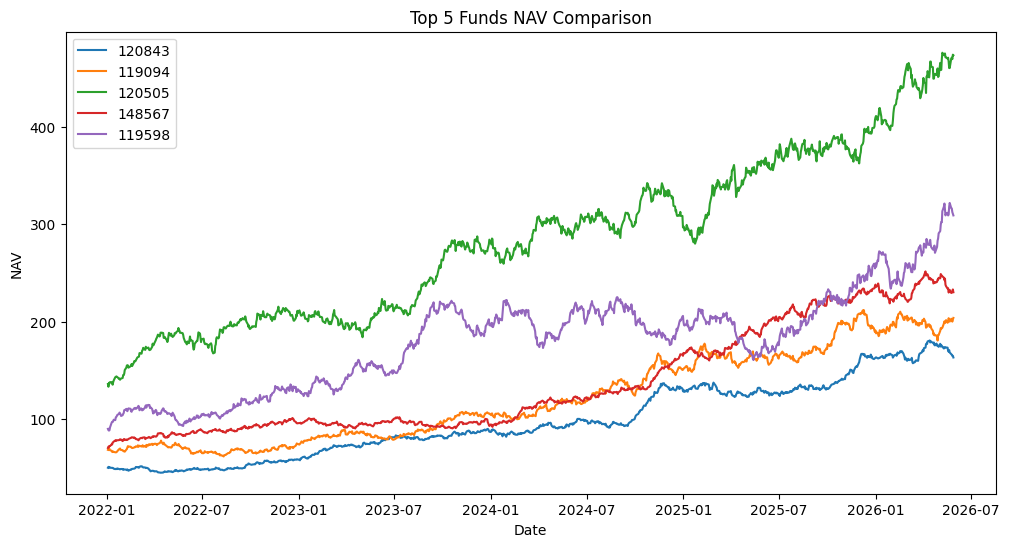

In [ ]:
import matplotlib.pyplot as plt

top5 = scorecard.head(5)["amfi_code"].tolist()

plt.figure(figsize=(12,6))

for fund in top5:

    fund_data = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=str(fund)
    )

plt.title("Top 5 Funds NAV Comparison")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()

plt.savefig(
    "../reports/benchmark_comparison.png"
)

plt.show()